# Gene Expression Dataset Exploration

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from feature_selection.src.preprocessing import train_test_val_split
from feature_selection.src.baseline.logistic_regression_random_baseline import *

In [2]:
DATA_PATH = "../data/SCANB.csv"
LABEL_PATH = "../data/sampleinfo_SCANB_t.csv"

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
TRAIN_PCT = 0.7
VALIDATION_PCT = 0.1
RANDOM_SEED = 2

In [5]:
df.head()

,Unnamed: 0,F1,F2,F3,F4,F5,F6,F9,F10,F11,...,F2841repl,F2860repl,F2872repl,F2877repl,F2911repl,F2912repl,F2958repl,F3057repl,F3085repl,F3135repl
0,A2M,-1.098234,0.110096,-1.779393,0.268360,0.616851,3.433406,-0.424064,0.357813,0.629575,...,0.340017,-0.427134,-0.811695,1.155090,-0.873224,-0.186538,-0.071234,1.535495,-2.769459,1.348425
1,A4GNT,-0.615048,-0.615048,-0.615048,-0.615048,-0.615048,-0.615048,-0.615048,-0.615048,3.324828,...,2.004878,0.408918,-0.615048,2.120522,-0.615048,2.274780,0.598461,1.185567,-0.615048,-0.615048
2,AAAS,-1.670827,0.248934,-0.422635,0.236302,-0.988261,-1.263231,-2.147768,-1.700644,0.055263,...,-0.807723,-1.566462,1.859718,-1.240860,1.058475,-0.234717,-0.501922,0.165044,0.883363,-1.641798
3,AACS,-0.539020,0.032084,0.392158,0.563540,-0.083663,-0.748093,-0.999103,-1.358139,2.157231,...,0.241122,-0.216516,0.841555,-1.019500,-0.108282,0.508552,0.663004,-0.257163,-0.884103,0.819606
4,AADAC,0.098325,0.262344,-0.711190,-0.373168,0.067739,-0.711190,-0.711190,-0.183505,-0.021691,...,-0.711190,2.818603,-0.711190,-0.711190,-0.711190,-0.711190,-0.711190,-0.711190,-0.056693,-0.711190


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9264 entries, 0 to 9263
Columns: 3070 entries, Unnamed: 0 to F3135repl
dtypes: float64(3069), object(1)
memory usage: 217.0+ MB


In [7]:
labels = pd.read_csv(LABEL_PATH)

In [8]:
labels.head()

,Unnamed: 0,samplename,ER,PAM50,time,event,Lympho,cluster2
0,1,F1,1,Basal,2367,0,2.602223,6
1,2,F2,2,LumA,2367,0,1.104544,5
2,3,F3,2,LumB,2168,1,0.581018,5
3,4,F4,2,LumA,2416,0,2.882004,6
4,5,F5,2,Normal,2389,0,1.013356,4


In [9]:
labels['is_lumA'] = labels.PAM50 == 'LumA'

In [10]:
labels.head()

,Unnamed: 0,samplename,ER,PAM50,time,event,Lympho,cluster2,is_lumA
0,1,F1,1,Basal,2367,0,2.602223,6,False
1,2,F2,2,LumA,2367,0,1.104544,5,True
2,3,F3,2,LumB,2168,1,0.581018,5,False
3,4,F4,2,LumA,2416,0,2.882004,6,True
4,5,F5,2,Normal,2389,0,1.013356,4,False


In [11]:
train, validation, test = train_test_val_split(labels, RANDOM_SEED, TRAIN_PCT, VALIDATION_PCT)

Running experiments: 100%|██████████| 10/10 [02:17<00:00, 13.75s/it]


Summary Statistics (Mean +/- Std Dev):



,features_num,variable,mean,std
0,10,f1-score,0.715280,0.048491
1,10,precision,0.716583,0.048612
2,10,recall,0.715332,0.048342
3,50,f1-score,0.815167,0.016873
4,50,precision,0.817040,0.017953
5,50,recall,0.814962,0.016831
6,100,f1-score,0.833684,0.010858
7,100,precision,0.834780,0.011697
8,100,recall,0.833566,0.010761
9,250,f1-score,0.844224,0.018446


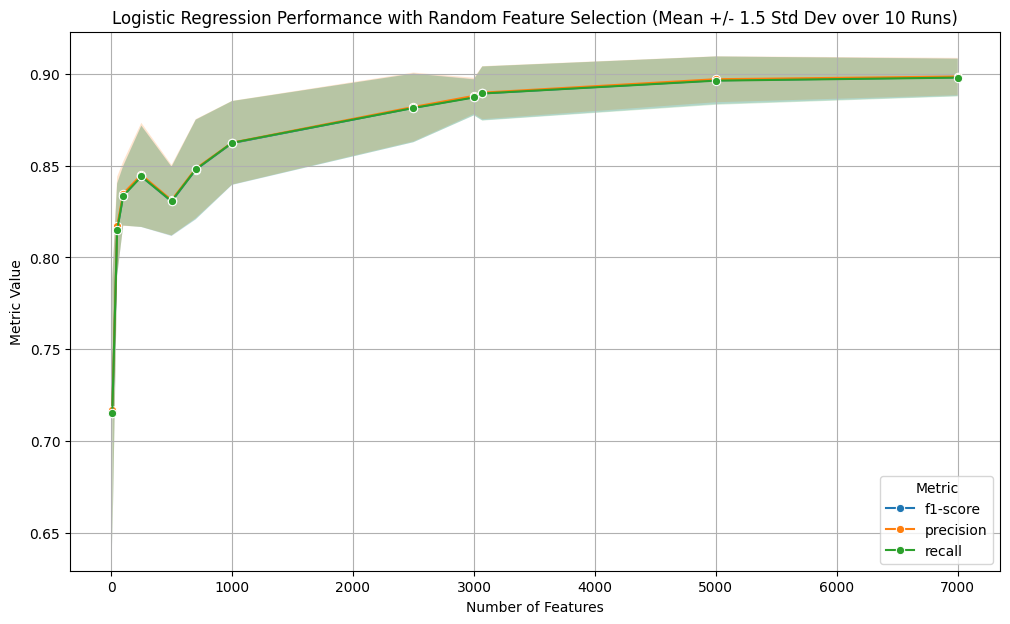

In [12]:
N_values = [10, 50, 100, 250, 500, 700, 1000, 2500, 3000, 5000, 7000, df.shape[1]-1]
plot_performance_with_stats(df, train, validation, N_values, RANDOM_SEED, num_runs=10, lr_C=np.inf)